# PyTorch 활성화 함수와 성능 비교 실습

핵심 주제는 활성화 함수(Activation Function)입니다. 활성화 함수는 신경망이 단순한 직선 계산을 넘어서 곡선 형태의 복잡한 패턴을 학습할 수 있게 만드는 중요한 구성 요소입니다.

다루는 활성화 함수는 다음 네 가지입니다.

- Sigmoid
- Tanh
- ReLU
- LeakyReLU



## 활성화 함수가 필요한 이유

신경망에서 `nn.Linear()` 층은 입력값에 가중치를 곱하고 편향을 더하는 선형 계산을 수행합니다. 수식으로 표현하면 `y = wx + b`입니다. 그런데 선형 계산만 여러 번 반복하면 층을 아무리 많이 쌓아도 결국 하나의 큰 선형 함수와 같은 효과가 됩니다. 즉, 은닉층을 여러 개 쌓아도 활성화 함수가 없으면 복잡한 곡선 패턴이나 비선형 분류 문제를 제대로 학습하기 어렵습니다.

활성화 함수는 선형 계산 결과에 비선형성을 추가합니다. 이 비선형성 덕분에 신경망은 XOR 문제, 이미지 분류, 음성 인식, 자연어 처리처럼 직선 하나로 설명하기 어려운 복잡한 문제를 학습할 수 있습니다.

PyTorch에서는 활성화 함수를 `torch.sigmoid`, `torch.tanh`, `nn.ReLU()`, `nn.LeakyReLU()`처럼 함수 또는 모듈 형태로 사용할 수 있습니다.

In [1]:
# 활성화 함수 실습을 위한 기본 라이브러리 준비

# torch는 PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, 수학 연산, 자동 미분, 신경망 학습 등에 사용됩니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# matplotlib.pyplot은 데이터와 학습 결과를 그래프로 시각화할 때 사용합니다.
import matplotlib.pyplot as plt

# random_split과 TensorDataset은 학습용/검증용 데이터셋을 구성할 때 사용합니다.
from torch.utils.data import TensorDataset, DataLoader, random_split

# 실행 결과를 매번 비슷하게 재현하기 위해 난수 시드를 고정합니다.
# 딥러닝 학습은 가중치 초기화와 데이터 셔플에 난수가 사용되므로, 시드를 고정하면 실험 비교가 쉬워집니다.
torch.manual_seed(42)

# 현재 노트북에서 사용하는 PyTorch 버전을 출력합니다.
print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cpu


## 활성화 함수 입력값 만들기

활성화 함수의 동작을 이해하려면 음수, 0, 양수가 모두 포함된 입력값을 넣어보는 것이 좋습니다. 여기서는 -5부터 5까지의 값을 일정한 간격으로 생성합니다. 이후 이 값에 Sigmoid, Tanh, ReLU, LeakyReLU를 각각 적용하여 출력값이 어떻게 달라지는지 확인합니다.

In [2]:
# 활성화 함수에 넣을 입력값 생성

# torch.linspace(start, end, steps)는 start부터 end까지 steps개만큼 균등한 간격의 숫자를 생성합니다.
# 여기서는 -5부터 5까지 200개의 값을 생성합니다.
x = torch.linspace(-5, 5, 200)

# 앞쪽 10개 값을 출력하여 어떤 값들이 들어있는지 확인합니다.
print('입력값 x의 앞부분:')
print(x[:10])

# Tensor의 전체 모양을 확인합니다.
# torch.Size([200])은 200개의 숫자가 일렬로 들어있는 1차원 Tensor라는 뜻입니다.
print('x의 shape:', x.shape)

입력값 x의 앞부분:
tensor([-5.0000, -4.9497, -4.8995, -4.8492, -4.7990, -4.7487, -4.6985, -4.6482,
        -4.5980, -4.5477])
x의 shape: torch.Size([200])


## Sigmoid 함수 설명과 테스트

Sigmoid 함수는 입력값을 0과 1 사이로 압축합니다. 그래서 과거에는 이진 분류 문제의 출력층에서 자주 사용되었습니다. 예를 들어 출력값이 0.8이면 1일 가능성이 높고, 0.2이면 0일 가능성이 높다고 해석할 수 있습니다.

그러나 Sigmoid는 입력값이 매우 크거나 매우 작을 때 기울기가 거의 0에 가까워집니다. 이로 인해 깊은 신경망에서는 역전파 과정에서 Gradient가 잘 전달되지 않는 문제가 발생할 수 있습니다. 이를 기울기 소실(Vanishing Gradient)이라고 합니다.

입력값 예시: tensor([-5.0000, -2.4874,  0.0251,  2.5377])
Sigmoid 출력 예시: tensor([0.0067, 0.0767, 0.5063, 0.9267])


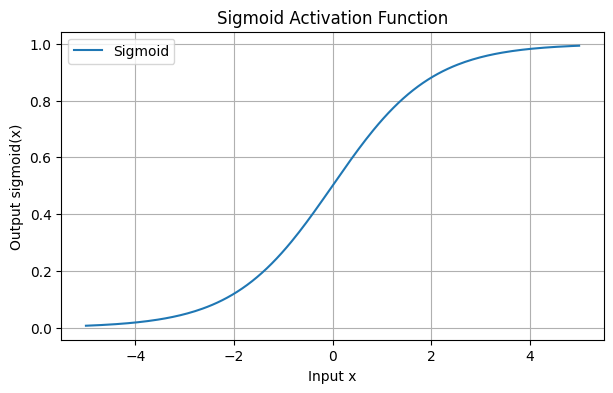

In [3]:
# Sigmoid 함수 테스트

# torch.sigmoid(x)는 입력 Tensor x의 각 원소에 Sigmoid 함수를 적용합니다.
# Sigmoid 출력값은 항상 0보다 크고 1보다 작습니다.
sigmoid_y = torch.sigmoid(x)

# 입력값 몇 개와 Sigmoid 출력값 몇 개를 비교해 봅니다.
print('입력값 예시:', x[::50])
print('Sigmoid 출력 예시:', sigmoid_y[::50])

# Sigmoid 함수를 그래프로 확인합니다.
plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), sigmoid_y.numpy(), label='Sigmoid')
plt.title('Sigmoid Activation Function')
plt.xlabel('Input x')
plt.ylabel('Output sigmoid(x)')
plt.grid(True)
plt.legend()
plt.show()

## Tanh 함수 설명과 테스트

Tanh 함수는 입력값을 -1과 1 사이로 압축합니다. Sigmoid가 0부터 1 사이의 값을 출력하는 것과 달리, Tanh는 음수와 양수를 모두 출력할 수 있습니다. 그래서 출력의 중심이 0에 가까워지는 장점이 있습니다.

하지만 Tanh 역시 입력값이 매우 크거나 매우 작으면 기울기가 0에 가까워집니다. 따라서 깊은 신경망에서는 Sigmoid와 마찬가지로 기울기 소실 문제가 발생할 수 있습니다.

입력값 예시: tensor([-5.0000, -2.4874,  0.0251,  2.5377])
Tanh 출력 예시: tensor([-0.9999, -0.9863,  0.0251,  0.9876])


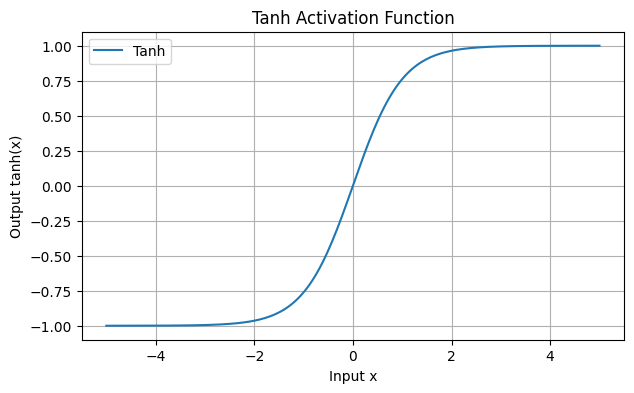

In [4]:
# Tanh 함수 테스트

# torch.tanh(x)는 입력 Tensor x의 각 원소에 Tanh 함수를 적용합니다.
# Tanh 출력값은 -1보다 크고 1보다 작습니다.
tanh_y = torch.tanh(x)

# 입력값 몇 개와 Tanh 출력값 몇 개를 비교합니다.
print('입력값 예시:', x[::50])
print('Tanh 출력 예시:', tanh_y[::50])

# Tanh 함수를 그래프로 확인합니다.
plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), tanh_y.numpy(), label='Tanh')
plt.title('Tanh Activation Function')
plt.xlabel('Input x')
plt.ylabel('Output tanh(x)')
plt.grid(True)
plt.legend()
plt.show()

## ReLU 함수 설명과 테스트

ReLU(Rectified Linear Unit)는 현재 딥러닝에서 가장 널리 사용되는 활성화 함수 중 하나입니다. ReLU는 입력값이 0보다 작으면 0을 출력하고, 0보다 크면 입력값을 그대로 출력합니다.

ReLU의 장점은 계산이 단순하고, 양수 구간에서 기울기가 1이므로 Gradient가 비교적 잘 전달된다는 점입니다. 하지만 음수 입력에서는 출력이 항상 0이 되기 때문에 일부 뉴런이 학습 중 완전히 죽어버리는 현상이 발생할 수 있습니다. 이를 Dying ReLU 문제라고 합니다.

입력값 예시: tensor([-5.0000, -2.4874,  0.0251,  2.5377])
ReLU 출력 예시: tensor([0.0000, 0.0000, 0.0251, 2.5377])


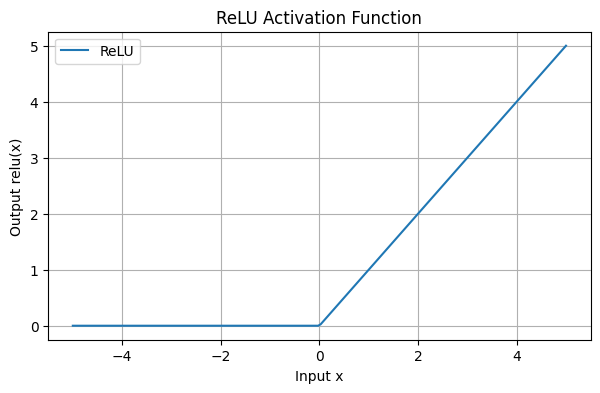

In [5]:
# ReLU 함수 테스트

# nn.ReLU()는 PyTorch에서 ReLU 활성화 함수를 모듈 형태로 생성합니다.
relu = nn.ReLU()

# 생성한 ReLU 모듈에 입력 Tensor x를 넣으면 각 원소에 ReLU가 적용됩니다.
relu_y = relu(x)

# 입력값 몇 개와 ReLU 출력값 몇 개를 비교합니다.
print('입력값 예시:', x[::50])
print('ReLU 출력 예시:', relu_y[::50])

# ReLU 함수를 그래프로 확인합니다.
plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), relu_y.numpy(), label='ReLU')
plt.title('ReLU Activation Function')
plt.xlabel('Input x')
plt.ylabel('Output relu(x)')
plt.grid(True)
plt.legend()
plt.show()

## LeakyReLU 함수 설명과 테스트

LeakyReLU는 ReLU의 단점을 보완하기 위해 만들어진 활성화 함수입니다. ReLU는 음수 입력을 모두 0으로 바꾸지만, LeakyReLU는 음수 입력에 아주 작은 기울기를 남겨 둡니다. 예를 들어 `negative_slope=0.01`이면 음수 입력에 대해 `0.01 * x`를 출력합니다.

이렇게 하면 음수 구간에서도 Gradient가 완전히 0이 되지 않으므로 Dying ReLU 문제를 어느 정도 완화할 수 있습니다.

입력값 예시: tensor([-5.0000, -2.4874,  0.0251,  2.5377])
LeakyReLU 출력 예시: tensor([-0.0500, -0.0249,  0.0251,  2.5377])


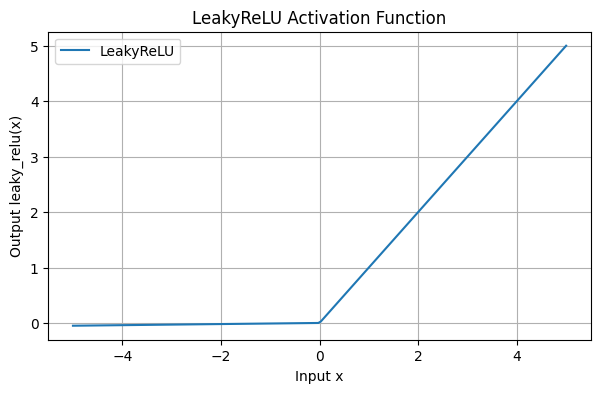

In [6]:
# LeakyReLU 함수 테스트

# nn.LeakyReLU(negative_slope=0.01)는 음수 입력에 대해 0.01배 값을 출력하는 활성화 함수입니다.
# negative_slope는 음수 구간에서 얼마나 작은 기울기를 남길지 결정하는 하이퍼파라미터입니다.
leaky_relu = nn.LeakyReLU(negative_slope=0.01)

# 생성한 LeakyReLU 모듈에 입력 Tensor x를 넣습니다.
leaky_relu_y = leaky_relu(x)

# 입력값 몇 개와 LeakyReLU 출력값 몇 개를 비교합니다.
print('입력값 예시:', x[::50])
print('LeakyReLU 출력 예시:', leaky_relu_y[::50])

# LeakyReLU 함수를 그래프로 확인합니다.
plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), leaky_relu_y.numpy(), label='LeakyReLU')
plt.title('LeakyReLU Activation Function')
plt.xlabel('Input x')
plt.ylabel('Output leaky_relu(x)')
plt.grid(True)
plt.legend()
plt.show()

## 네 가지 활성화 함수 그래프 비교

활성화 함수를 각각 따로 보는 것도 중요하지만, 한 그래프에서 비교하면 차이를 더 쉽게 이해할 수 있습니다. Sigmoid는 0과 1 사이로 압축되고, Tanh는 -1과 1 사이로 압축됩니다. ReLU는 음수를 0으로 만들고 양수를 그대로 통과시킵니다. LeakyReLU는 음수도 아주 작게 통과시킵니다.

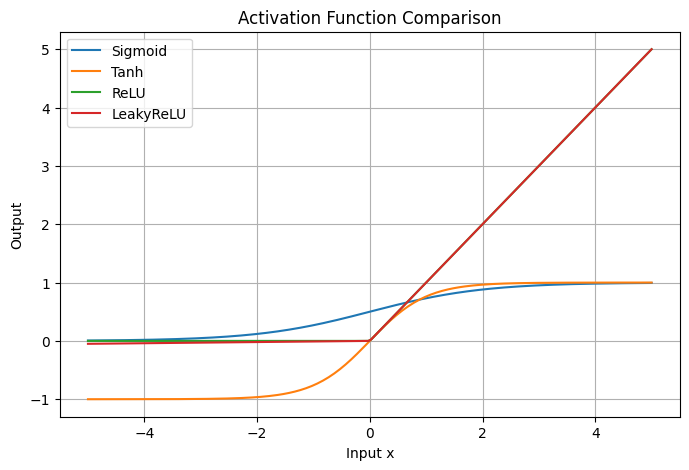

In [7]:
# 네 가지 활성화 함수 그래프 비교

# 각 활성화 함수의 출력값을 다시 계산합니다.
sigmoid_y = torch.sigmoid(x)
tanh_y = torch.tanh(x)
relu_y = nn.ReLU()(x)
leaky_relu_y = nn.LeakyReLU(negative_slope=0.01)(x)

# 하나의 그래프에 네 가지 활성화 함수를 함께 표시합니다.
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), sigmoid_y.numpy(), label='Sigmoid')
plt.plot(x.numpy(), tanh_y.numpy(), label='Tanh')
plt.plot(x.numpy(), relu_y.numpy(), label='ReLU')
plt.plot(x.numpy(), leaky_relu_y.numpy(), label='LeakyReLU')
plt.title('Activation Function Comparison')
plt.xlabel('Input x')
plt.ylabel('Output')
plt.grid(True)
plt.legend()
plt.show()

## 활성화 함수의 기울기 확인

역전파에서는 손실 함수가 각 가중치에 미치는 영향을 미분값, 즉 Gradient로 계산합니다. 활성화 함수의 기울기가 너무 작으면 이전 층으로 Gradient가 거의 전달되지 않습니다. Sigmoid와 Tanh는 입력값이 매우 크거나 작을 때 기울기가 0에 가까워집니다. 반면 ReLU는 양수 구간에서 기울기가 1이므로 깊은 신경망에서 비교적 안정적으로 학습됩니다.

다음 코드는 PyTorch의 자동 미분 기능을 이용하여 각 활성화 함수의 기울기를 직접 계산합니다.

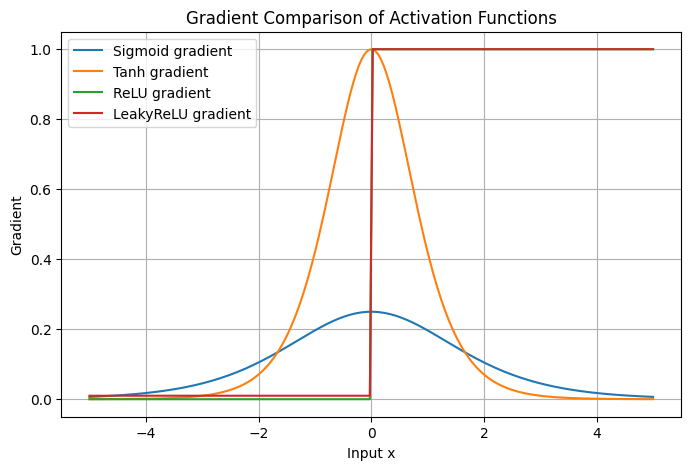

In [8]:
# 자동 미분으로 활성화 함수의 기울기 확인

# requires_grad=True는 PyTorch에게 이 Tensor에 대한 미분값을 추적하라고 알려주는 옵션입니다.
grad_x = torch.linspace(-5, 5, 200, requires_grad=True)

# 각 활성화 함수의 출력 합계를 계산합니다.
# 합계를 사용하는 이유는 backward()가 스칼라 값에 대해 가장 간단하게 실행되기 때문입니다.
sigmoid_sum = torch.sigmoid(grad_x).sum()
tanh_sum = torch.tanh(grad_x).sum()
relu_sum = nn.ReLU()(grad_x).sum()
leaky_sum = nn.LeakyReLU(negative_slope=0.01)(grad_x).sum()

# 여러 함수의 gradient를 각각 구하기 위해 torch.autograd.grad를 사용합니다.
# retain_graph=True는 같은 계산 그래프에서 여러 번 gradient를 계산할 수 있게 해줍니다.
sigmoid_grad = torch.autograd.grad(sigmoid_sum, grad_x, retain_graph=True)[0]
tanh_grad = torch.autograd.grad(tanh_sum, grad_x, retain_graph=True)[0]
relu_grad = torch.autograd.grad(relu_sum, grad_x, retain_graph=True)[0]
leaky_grad = torch.autograd.grad(leaky_sum, grad_x, retain_graph=True)[0]

# 계산된 기울기를 그래프로 비교합니다.
plt.figure(figsize=(8, 5))
plt.plot(grad_x.detach().numpy(), sigmoid_grad.detach().numpy(), label='Sigmoid gradient')
plt.plot(grad_x.detach().numpy(), tanh_grad.detach().numpy(), label='Tanh gradient')
plt.plot(grad_x.detach().numpy(), relu_grad.detach().numpy(), label='ReLU gradient')
plt.plot(grad_x.detach().numpy(), leaky_grad.detach().numpy(), label='LeakyReLU gradient')
plt.title('Gradient Comparison of Activation Functions')
plt.xlabel('Input x')
plt.ylabel('Gradient')
plt.grid(True)
plt.legend()
plt.show()

## 성능 비교용 데이터셋 생성

활성화 함수의 성능을 비교하기 위해 단순한 선형 데이터가 아니라 곡선 형태를 가진 이진 분류 데이터를 생성합니다. 이 데이터는 두 개의 반달 모양 클래스가 서로 섞여 있는 구조입니다. 직선 하나로는 분류가 어렵기 때문에 활성화 함수의 차이를 확인하기에 적합합니다.

외부 데이터 파일을 사용하지 않고 PyTorch만으로 데이터를 직접 생성하므로 Google Colab에서도 바로 실행할 수 있습니다.

X_data shape: torch.Size([1000, 2])
y_data shape: torch.Size([1000, 1])


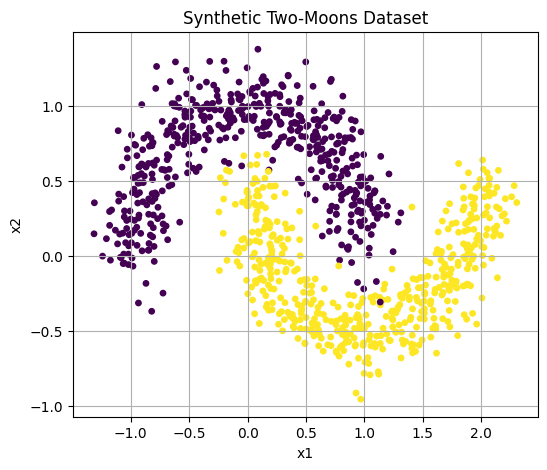

In [9]:
# PyTorch만 사용하여 반달 모양 이진 분류 데이터 생성

# make_moons_torch 함수는 두 개의 반달 모양 클래스를 생성하는 사용자 정의 함수입니다.
def make_moons_torch(n_samples=1000, noise=0.15):
    # n_samples의 절반은 첫 번째 반달, 나머지 절반은 두 번째 반달에 배치합니다.
    n_half = n_samples // 2

    # 0부터 pi까지의 각도를 균등하게 생성합니다.
    theta1 = torch.linspace(0, torch.pi, n_half)
    theta2 = torch.linspace(0, torch.pi, n_samples - n_half)

    # 첫 번째 반달의 x, y 좌표를 생성합니다.
    x1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=1)

    # 두 번째 반달의 x, y 좌표를 생성합니다.
    # 첫 번째 반달을 뒤집고 오른쪽 아래로 이동시킨 형태입니다.
    x2 = torch.stack([1 - torch.cos(theta2), -torch.sin(theta2) + 0.5], dim=1)

    # 두 반달 데이터를 하나로 합칩니다.
    X = torch.cat([x1, x2], dim=0)

    # 첫 번째 반달의 정답은 0, 두 번째 반달의 정답은 1로 지정합니다.
    y = torch.cat([torch.zeros(n_half), torch.ones(n_samples - n_half)], dim=0).view(-1, 1)

    # 데이터에 약간의 잡음을 추가하여 현실적인 분류 문제로 만듭니다.
    X = X + noise * torch.randn_like(X)

    # 데이터를 무작위 순서로 섞습니다.
    indices = torch.randperm(n_samples)
    X = X[indices]
    y = y[indices]

    return X.float(), y.float()

# 데이터셋을 생성합니다.
X_data, y_data = make_moons_torch(n_samples=1000, noise=0.15)

# 생성된 데이터의 모양을 확인합니다.
print('X_data shape:', X_data.shape)
print('y_data shape:', y_data.shape)

# 데이터를 산점도로 시각화합니다.
plt.figure(figsize=(6, 5))
plt.scatter(X_data[:, 0].numpy(), X_data[:, 1].numpy(), c=y_data.squeeze().numpy(), s=15)
plt.title('Synthetic Two-Moons Dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

## 학습용 데이터와 검증용 데이터 분리

모델 성능을 공정하게 비교하려면 학습에 사용한 데이터와 평가에 사용할 데이터를 분리해야 합니다. 학습 데이터는 모델의 가중치와 편향을 조정하는 데 사용하고, 검증 데이터는 학습된 모델이 새로운 데이터에서도 잘 작동하는지 확인하는 데 사용합니다.

여기서는 전체 데이터의 80%를 학습용으로, 20%를 검증용으로 사용합니다.

In [10]:
# 학습용 데이터와 검증용 데이터 분리

# TensorDataset은 입력 데이터 X와 정답 데이터 y를 하나의 데이터셋으로 묶어줍니다.
dataset = TensorDataset(X_data, y_data)

# 전체 데이터 개수를 확인합니다.
total_size = len(dataset)

# 학습 데이터는 전체의 80%로 설정합니다.
train_size = int(total_size * 0.8)

# 검증 데이터는 나머지 20%로 설정합니다.
valid_size = total_size - train_size

# random_split은 데이터셋을 지정한 크기대로 무작위 분할합니다.
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

# DataLoader는 데이터를 mini-batch 단위로 나누어 모델에 공급합니다.
# shuffle=True는 학습할 때마다 데이터 순서를 섞어 모델이 순서에 외우지 않도록 도와줍니다.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 검증 데이터는 평가만 하므로 일반적으로 shuffle=False를 사용합니다.
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print('학습 데이터 개수:', len(train_dataset))
print('검증 데이터 개수:', len(valid_dataset))

학습 데이터 개수: 800
검증 데이터 개수: 200


##  활성화 함수를 바꿔 끼울 수 있는 MLP 모델 정의

활성화 함수의 성능을 비교하려면 모델 구조는 동일하게 두고 활성화 함수만 바꾸어야 합니다. 그래야 성능 차이가 모델 구조 때문인지, 활성화 함수 때문인지 구분할 수 있습니다.

다음 `ActivationMLP` 클래스는 입력층, 은닉층 2개, 출력층으로 구성되어 있습니다. 생성자에서 활성화 함수 이름을 전달하면 해당 활성화 함수를 사용하는 모델이 만들어집니다.

In [11]:
# 활성화 함수를 선택할 수 있는 MLP 모델 정의

class ActivationMLP(nn.Module):
    # __init__은 모델 객체가 생성될 때 한 번 실행되는 초기화 메서드입니다.
    def __init__(self, activation_name):
        # 부모 클래스(nn.Module)의 초기화 기능을 먼저 실행합니다.
        super().__init__()

        # 문자열로 전달된 활성화 함수 이름에 따라 사용할 활성화 함수를 선택합니다.
        if activation_name == 'Sigmoid':
            activation = nn.Sigmoid()
        elif activation_name == 'Tanh':
            activation = nn.Tanh()
        elif activation_name == 'ReLU':
            activation = nn.ReLU()
        elif activation_name == 'LeakyReLU':
            activation = nn.LeakyReLU(negative_slope=0.01)
        else:
            # 정의되지 않은 활성화 함수 이름이 들어오면 오류를 발생시킵니다.
            raise ValueError('지원하지 않는 활성화 함수입니다.')

        # nn.Sequential은 여러 층을 순서대로 연결하는 컨테이너입니다.
        self.network = nn.Sequential(
            # 입력 특성 2개를 받아 은닉 뉴런 16개로 변환합니다.
            nn.Linear(2, 16),
            # 첫 번째 은닉층 뒤에 활성화 함수를 적용합니다.
            activation,
            # 은닉 뉴런 16개를 다시 은닉 뉴런 16개로 변환합니다.
            nn.Linear(16, 16),
            # 두 번째 은닉층 뒤에도 같은 활성화 함수를 적용합니다.
            activation,
            # 마지막 출력층은 이진 분류를 위해 출력값 1개를 만듭니다.
            nn.Linear(16, 1),
            # Sigmoid는 최종 출력값을 0~1 사이 확률처럼 바꿉니다.
            nn.Sigmoid()
        )

    # forward는 입력 데이터가 모델을 통과하는 순전파 과정을 정의합니다.
    def forward(self, x):
        return self.network(x)

# 모델이 정상적으로 생성되는지 테스트합니다.
test_model = ActivationMLP('ReLU')
print(test_model)

ActivationMLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


##  학습 함수와 평가 함수 작성

성능 비교 실험에서는 같은 학습 절차를 여러 활성화 함수 모델에 반복 적용해야 합니다. 따라서 학습 과정을 함수로 만들어 두면 코드가 깔끔해지고 실험 조건을 동일하게 유지할 수 있습니다.

아래 함수는 Adam Optimizer와 BCELoss를 사용합니다. BCELoss는 출력이 0 또는 1인 이진 분류 문제에서 많이 사용하는 손실 함수입니다.

In [12]:
# 모델 학습 함수와 정확도 평가 함수 정의

# evaluate_accuracy 함수는 모델의 분류 정확도를 계산합니다.
def evaluate_accuracy(model, data_loader):
    # model.eval()은 모델을 평가 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 때 학습 모드와 평가 모드의 동작이 달라집니다.
    model.eval()

    # 맞힌 개수와 전체 개수를 저장할 변수를 초기화합니다.
    correct = 0
    total = 0

    # torch.no_grad()는 평가 중 gradient 계산을 하지 않게 하여 메모리 사용량과 계산량을 줄입니다.
    with torch.no_grad():
        # DataLoader에서 mini-batch 단위로 데이터를 가져옵니다.
        for batch_X, batch_y in data_loader:
            # 모델에 입력 데이터를 넣어 예측 확률을 계산합니다.
            outputs = model(batch_X)

            # 출력 확률이 0.5 이상이면 1, 미만이면 0으로 분류합니다.
            predicted = (outputs >= 0.5).float()

            # 예측값과 실제값이 같은 개수를 누적합니다.
            correct += (predicted == batch_y).sum().item()

            # 전체 데이터 개수를 누적합니다.
            total += batch_y.size(0)

    # 정확도는 맞힌 개수를 전체 개수로 나눈 값입니다.
    return correct / total


# train_model 함수는 하나의 활성화 함수 모델을 학습하고 학습 이력을 반환합니다.
def train_model(activation_name, epochs=200, lr=0.01):
    # 비교 실험을 공정하게 하기 위해 각 모델 생성 전에 난수 시드를 고정합니다.
    torch.manual_seed(42)

    # 전달받은 활성화 함수 이름으로 모델을 생성합니다.
    model = ActivationMLP(activation_name)

    # BCELoss는 이진 분류에서 예측 확률과 실제 정답 사이의 오차를 계산합니다.
    criterion = nn.BCELoss()

    # Adam은 학습률을 적응적으로 조정하는 최적화 알고리즘입니다.
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 학습 과정의 손실값과 정확도를 저장할 리스트입니다.
    history = {
        'train_loss': [],
        'valid_acc': []
    }

    # 지정한 epoch 수만큼 학습을 반복합니다.
    for epoch in range(epochs):
        # model.train()은 모델을 학습 모드로 전환합니다.
        model.train()

        # 한 epoch 동안의 전체 손실을 저장할 변수입니다.
        total_loss = 0.0

        # mini-batch 단위로 학습 데이터를 가져옵니다.
        for batch_X, batch_y in train_loader:
            # 1단계: 순전파를 수행하여 예측값을 계산합니다.
            outputs = model(batch_X)

            # 2단계: 예측값과 실제값의 차이를 손실 함수로 계산합니다.
            loss = criterion(outputs, batch_y)

            # 3단계: 이전 mini-batch에서 계산된 gradient를 초기화합니다.
            optimizer.zero_grad()

            # 4단계: 역전파를 수행하여 각 파라미터의 gradient를 계산합니다.
            loss.backward()

            # 5단계: Adam Optimizer가 gradient를 이용해 weight와 bias를 업데이트합니다.
            optimizer.step()

            # 현재 mini-batch의 손실값을 누적합니다.
            total_loss += loss.item() * batch_X.size(0)

        # 한 epoch의 평균 손실을 계산합니다.
        avg_loss = total_loss / len(train_dataset)

        # 검증 데이터에 대한 정확도를 계산합니다.
        valid_acc = evaluate_accuracy(model, valid_loader)

        # 이력을 저장합니다.
        history['train_loss'].append(avg_loss)
        history['valid_acc'].append(valid_acc)

    # 학습된 모델과 학습 이력을 반환합니다.
    return model, history

## 네 가지 활성화 함수 성능 비교 학습

이제 Sigmoid, Tanh, ReLU, LeakyReLU를 같은 조건에서 학습시킵니다. 모든 모델은 같은 구조를 사용하고, 활성화 함수만 다릅니다. 손실 함수는 BCELoss를 사용하고, Optimizer는 Adam을 사용합니다.

결과 비교에서는 최종 검증 정확도와 최종 학습 손실값을 확인합니다.

In [13]:
# 네 가지 활성화 함수 모델 학습 및 성능 비교

# 비교할 활성화 함수 이름 목록입니다.
activation_names = ['Sigmoid', 'Tanh', 'ReLU', 'LeakyReLU']

# 각 활성화 함수별 학습 결과를 저장할 딕셔너리입니다.
results = {}

# 각 활성화 함수에 대해 동일한 조건으로 학습을 반복합니다.
for activation_name in activation_names:
    print(f'현재 학습 중인 활성화 함수: {activation_name}')

    # train_model 함수를 호출하여 모델을 학습합니다.
    model, history = train_model(activation_name, epochs=200, lr=0.01)

    # 최종 학습 손실과 최종 검증 정확도를 저장합니다.
    results[activation_name] = {
        'model': model,
        'history': history,
        'final_loss': history['train_loss'][-1],
        'final_acc': history['valid_acc'][-1]
    }

    # 각 활성화 함수의 최종 결과를 출력합니다.
    print(f'{activation_name} 최종 학습 손실: {history["train_loss"][-1]:.4f}')
    print(f'{activation_name} 최종 검증 정확도: {history["valid_acc"][-1]:.4f}')
    print('-' * 50)

현재 학습 중인 활성화 함수: Sigmoid
Sigmoid 최종 학습 손실: 0.2730
Sigmoid 최종 검증 정확도: 0.9350
--------------------------------------------------
현재 학습 중인 활성화 함수: Tanh
Tanh 최종 학습 손실: 0.0332
Tanh 최종 검증 정확도: 1.0000
--------------------------------------------------
현재 학습 중인 활성화 함수: ReLU
ReLU 최종 학습 손실: 0.0249
ReLU 최종 검증 정확도: 1.0000
--------------------------------------------------
현재 학습 중인 활성화 함수: LeakyReLU
LeakyReLU 최종 학습 손실: 0.0248
LeakyReLU 최종 검증 정확도: 1.0000
--------------------------------------------------


## 학습 손실과 검증 정확도 그래프 비교

성능 비교에서는 최종 숫자만 보는 것보다 학습 과정 전체를 함께 확인하는 것이 중요합니다. 어떤 활성화 함수는 초반에는 느리게 학습되지만 후반에 좋아질 수 있고, 어떤 함수는 초반에는 빠르게 좋아지지만 일정 수준에서 멈출 수 있습니다.

아래 그래프는 각 활성화 함수의 학습 손실과 검증 정확도가 epoch에 따라 어떻게 변화하는지 보여줍니다.

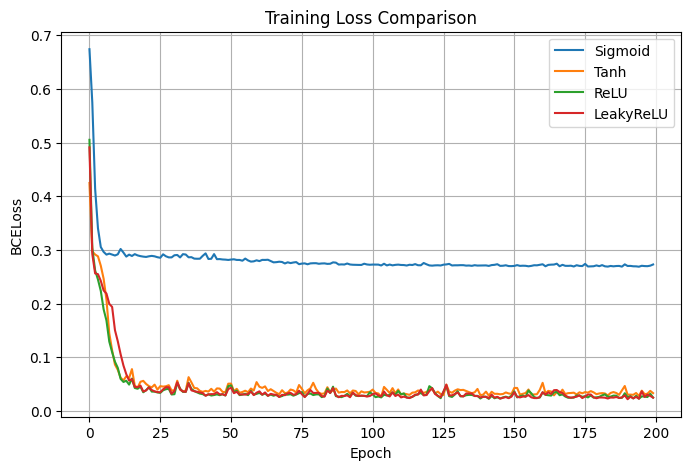

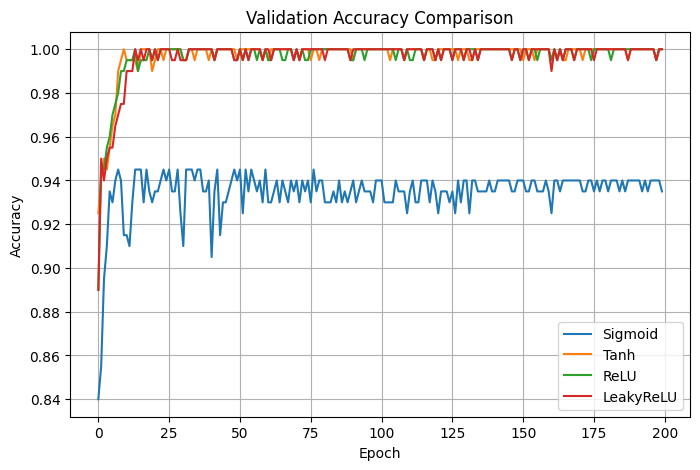

In [14]:
# 활성화 함수별 학습 손실과 검증 정확도 시각화

# 학습 손실 그래프를 그립니다.
plt.figure(figsize=(8, 5))
for activation_name in activation_names:
    # 각 활성화 함수의 train_loss 이력을 가져옵니다.
    train_loss = results[activation_name]['history']['train_loss']

    # epoch에 따른 손실 변화를 선 그래프로 표시합니다.
    plt.plot(train_loss, label=activation_name)

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('BCELoss')
plt.grid(True)
plt.legend()
plt.show()

# 검증 정확도 그래프를 그립니다.
plt.figure(figsize=(8, 5))
for activation_name in activation_names:
    # 각 활성화 함수의 valid_acc 이력을 가져옵니다.
    valid_acc = results[activation_name]['history']['valid_acc']

    # epoch에 따른 검증 정확도 변화를 선 그래프로 표시합니다.
    plt.plot(valid_acc, label=activation_name)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

## 성능 비교 결과 정리와 해석

활성화 함수 성능은 데이터 구조, 모델 깊이, 학습률, 초기 가중치, Optimizer에 따라 달라질 수 있습니다. 일반적으로 Sigmoid와 Tanh는 기울기 소실 문제가 발생할 수 있어 깊은 신경망에서는 학습이 느려질 수 있습니다. ReLU는 계산이 빠르고 양수 구간에서 Gradient가 잘 전달되어 기본 활성화 함수로 널리 사용됩니다. LeakyReLU는 ReLU의 음수 구간 문제를 보완하기 때문에 일부 데이터에서는 ReLU보다 안정적인 성능을 보일 수 있습니다.

이번 실습의 핵심 결론은 다음과 같습니다.

첫째, 활성화 함수는 신경망에 비선형성을 추가하여 복잡한 패턴을 학습하게 만든다.  
둘째, Sigmoid와 Tanh는 출력 범위가 제한되어 있으나 기울기 소실 문제가 발생할 수 있다.  
셋째, ReLU는 딥러닝에서 가장 기본적으로 사용되는 활성화 함수이다.  
넷째, LeakyReLU는 ReLU의 Dying ReLU 문제를 완화하기 위한 대안이다.  
다섯째, 실제 프로젝트에서는 여러 활성화 함수를 동일 조건에서 비교 실험한 후 선택하는 것이 좋다.

In [16]:
# 최종 성능 비교 표 출력

# 성능 결과를 보기 좋게 출력하기 위해 pandas를 사용합니다.
# pandas는 표 형태의 데이터를 다룰 때 편리한 라이브러리입니다.
import pandas as pd

# 결과 표에 넣을 데이터를 리스트로 구성합니다.
summary_rows = []

# 각 활성화 함수별 최종 성능을 하나씩 정리합니다.
for activation_name in activation_names:
    summary_rows.append({
        '활성화 함수': activation_name,
        '최종 학습 손실': results[activation_name]['final_loss'],
        '최종 검증 정확도': results[activation_name]['final_acc']
    })

# 리스트를 DataFrame으로 변환합니다.
summary_df = pd.DataFrame(summary_rows)

# 검증 정확도가 높은 순서로 정렬합니다.
summary_df = summary_df.sort_values(by='최종 검증 정확도', ascending=False)

# 정리된 성능 비교표를 출력합니다.
print(summary_df)

# 가장 높은 검증 정확도를 기록한 활성화 함수를 찾습니다.
best_activation = summary_df.iloc[0]['활성화 함수']

print('가장 좋은 성능을 보인 활성화 함수:', best_activation)

      활성화 함수  최종 학습 손실  최종 검증 정확도
1       Tanh  0.033173      1.000
2       ReLU  0.024886      1.000
3  LeakyReLU  0.024793      1.000
0    Sigmoid  0.272956      0.935
가장 좋은 성능을 보인 활성화 함수: Tanh
